# Adatbányászati elemzés: Adminisztratív költségek vizsgálata

Ez a jegyzőkönyv a `gazdmut` (vállalati demográfia) és a `szamla` (tranzakciós adatok) táblák elemzését tartalmazza. A cél a vállalkozások adminisztratív terheinek és költési szokásainak feltérképezése.

### 1. Adatbetöltés és előkészítés
Az elemzés első lépéseként betöltjük a szükséges Python könyvtárakat és a forrásfájlokat. 

**Adatminőségi és módszertani megjegyzések:**
* **Duplikációkezelés:** Mivel a számlák kategorizálása keresőszavakkal történt, egy bizonylat több kategóriába is besorolásra kerülhetett. Az aggregált pénzügyi mutatók (pl. összforgalom) torzításmentes számításához létrehozzuk a `szamla_unique` objektumot.
* **Adatkapcsolás:** A két táblát a vállalatok egyedi azonosítója mentén kapcsoljuk össze. `Left join` típust alkalmazunk, hogy a tranzakcióval nem rendelkező vállalatok is a mintában maradjanak, így pontosabb képet kapunk a teljes sokaságról.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Adatok betöltése
gazdmut = pd.read_csv('gazdmut.csv')
szamla = pd.read_csv('szamla.csv')

# Adatminőségi ellenőrzés: Mivel egy számla több kategóriába is bekerülhetett, 
# az összesített statisztikáknál (pl. összforgalom) vigyáznunk kell a duplikált összegekre.
szamla_unique = szamla.drop_duplicates(subset=['ESST_ID'])

# Táblák összekapcsolása (Left join, hogy a számla nélküli cégek is megmaradjanak az elemzéshez)
df = pd.merge(szamla, gazdmut, left_on='V_ADOSZAM_TORZSSZAM_DEP', right_on='AA_AZON', how='left')

print(f"Összesített rekordok száma: {len(df)}")
print(f"Egyedi vállalatok száma a mintában: {gazdmut['AA_AZON'].nunique()}")

Összesített rekordok száma: 136868
Egyedi vállalatok száma a mintában: 935


### 2. Alapvető statisztikai mutatók meghatározása szegmensenként

Ebben a szakaszban megvizsgáljuk, hogyan oszlanak meg az adminisztratív kiadások a különböző vállalatméretek között. Az elemzés során nemcsak az **átlagot**, hanem a **mediánt** is kiszámítjuk. 

**Szakmai indoklás:** A pénzügyi és számlaadatok gyakran tartalmaznak kiugró értékeket (outliers), amelyek az átlagot jelentősen eltolhatják a valóságtól. A medián (középérték) használata robusztusabb képet ad a "tipikus" vállalati költésről. A `nunique` függvény segítségével pedig pontosan látjuk, hogy az egyes kategóriákban hány egyedi gazdasági szereplő generálta a forgalmat.

In [17]:
# Vállalatméret szerinti csoportosítás
stats = df.groupby('VALLALATMERET').agg({
    'AA_AZON': 'nunique',
    'X_BRUTTO_HUF': ['sum', 'mean', 'median']
}).reset_index()

stats.columns = ['Vállalatméret', 'Cégek száma', 'Összes költés (HUF)', 'Átlagos számlaérték', 'Medián számlaérték']
display(stats)

,Vállalatméret,Cégek száma,Összes költés (HUF),Átlagos számlaérték,Medián számlaérték
0,kis,220,1.076182e+10,218049.215318,60708.0
1,kozep 100 alatt,23,3.466021e+09,442715.612211,144503.0
2,kozep 100 felett,17,1.760048e+09,431701.708364,80009.0
3,mikro,667,3.362222e+09,46795.675486,26189.0
4,nagy,8,1.266139e+09,336918.292177,62764.0


# 3. Vizualizáció: A költési struktúra és tranzakciós aktivitás feltérképezése

A leíró statisztika után vizuálisan is szemléltetjük a legfontosabb jellemzőt. Az alábbi ábra az adminisztratív szolgáltatási kategóriák szerinti megoszlást mutatja be két szempontból:

1.  **Sávdiagram (bal tengely):** Az összesített brutto költés (HUF) kategóriánként. Ez megmutatja a pénzügyi súlypontokat.
2.  **Vonaldiagram (jobb tengely):** Az egyedi számlák darabszáma kategóriánként. Ez a tranzakciós aktivitást és a szolgáltatások igénybevételének gyakoriságát jelzi.

**Módszertani megjegyzés:** Ebben a vizualizációban a teljes `df` adatbázist használjuk (nem a `szamla_unique`-t), mivel a célunk a *szolgáltatási kategóriák* összehasonlítása, és a feladatleírás szerint egy számla több kategóriában is érvényesen szerepelhet. Így minden kategória megkapja a neki járó költést.

C:\Users\USER\AppData\Local\Temp\ipykernel_7296\947467851.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(


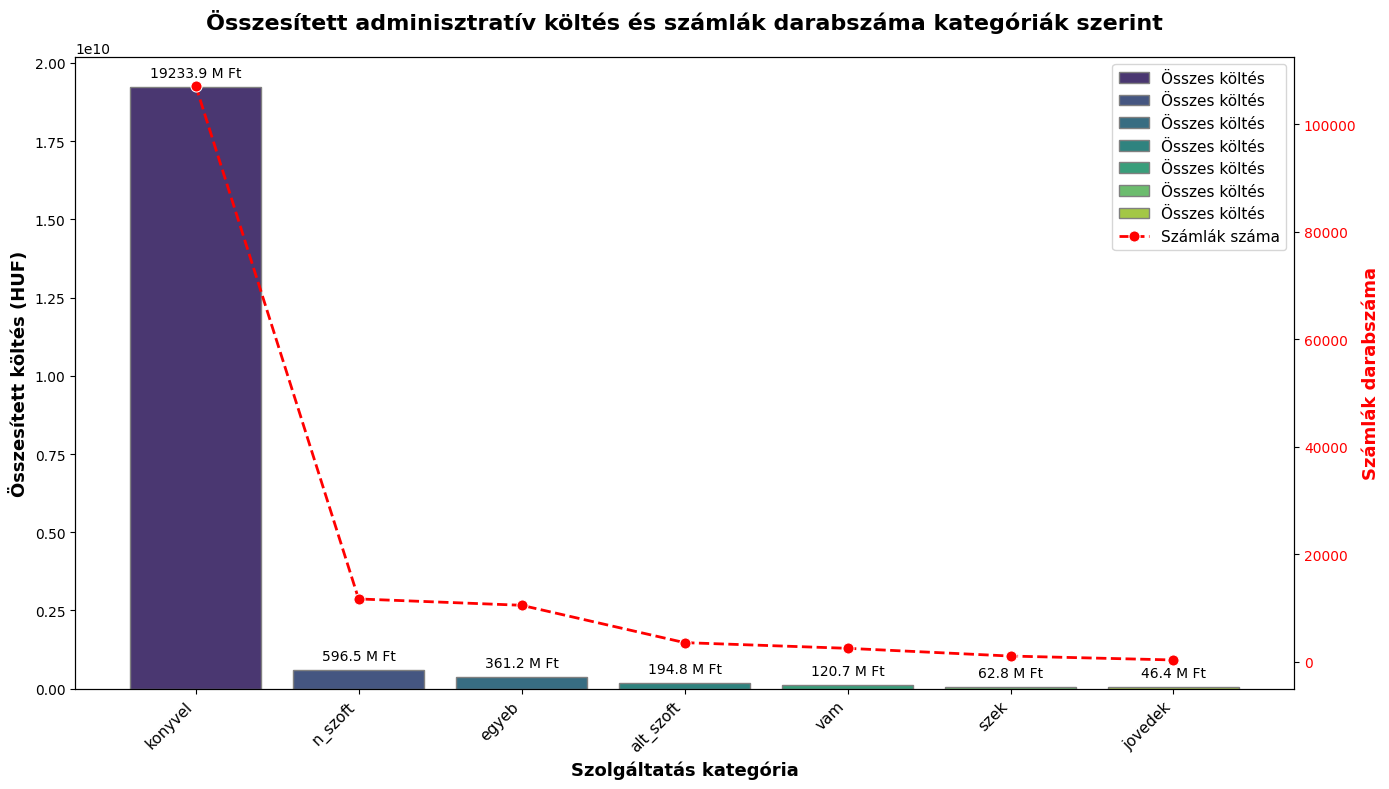

In [18]:
import numpy as np

# 1. Adatok előkészítése a vizualizációhoz
# Kategóriák szerinti csoportosítás: összeg és darabszám (mivel a kategórián belüli számlák már egyediek a korábbi megjegyzések szerint)
cat_stats = df.groupby('KATEGORIA').agg({
    'X_BRUTTO_HUF': ['sum', 'count']
}).reset_index()

# Oszlopnevek tisztázása
cat_stats.columns = ['Kategoria', 'Osszes_Koltes', 'Szamlak_Szama']

# Rendezés az összes költés szerint csökkenő sorrendbe a jobb olvashatóságért
cat_stats = cat_stats.sort_values(by='Osszes_Koltes', ascending=False)


# 2. A kombinált ábra elkészítése (Publikáció-kész minőség)
plt.figure(figsize=(14, 8))
# sns.set_style("whitegrid") # NAV stílushoz illeszkedő letisztultabb stílus, ha elérhető

# A sávdiagram (Osszes_Koltes)
bar = sns.barplot(
    data=cat_stats, 
    x='Kategoria', 
    y='Osszes_Koltes', 
    palette='viridis', # Profi, színvak-barát színpaletta
    edgecolor='gray',
    label='Összes költés'
)

# Bal oldali tengely formázása (HUF milliárdokban/milliókban)
plt.title('Összesített adminisztratív költés és számlák darabszáma kategóriák szerint', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Szolgáltatás kategória', fontsize=13, fontweight='bold')
plt.ylabel('Összesített költés (HUF)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11) # Feliratok elforgatása

# Értékek megjelenítése a sávok felett (forint formátumban, pl. millió Ft)
for p in bar.patches:
    bar.annotate(f"{p.get_height() / 1e6:.1f} M Ft", 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 10), 
                   textcoords = 'offset points',
                   fontsize=10)


# 3. Második tengely (Szamlak_Szama) - Vonaldiagram
ax2 = plt.gca().twinx() # Létrehozunk egy másodlagos y-tengelyt

# Vonaldiagram a számlák számáról
sns.lineplot(
    data=cat_stats, 
    x='Kategoria', 
    y='Szamlak_Szama', 
    color='red', 
    marker='o', 
    markersize=8,
    linewidth=2,
    linestyle='--', # Megkülönböztetés
    ax=ax2,
    label='Számlák száma'
)

# Jobb oldali tengely formázása (Darabszám)
ax2.set_ylabel('Számlák darabszáma', fontsize=13, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Közös legenda összeállítása
lines, labels = bar.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize=11)

plt.tight_layout() # Biztosítja, hogy semmi se lógjon le az ábráról
plt.show()

## 4. Vizualizáció: A költések belső eloszlása és a kiugró értékek azonosítása

Az előző ábrán az összesített összegeket láttuk. Most azt vizsgáljuk meg, hogy az egyes kategóriákon *belül* hogyan oszlanak meg a számlaértékek. Ehhez **Boxplot (dobozdiagram)** techninkát alkalmazunk.

**Szakmai indoklás:** A Boxplot segítségével egyszerre látjuk:
* a **mediánt** (a doboz belsejében lévő vonal),
* az adatok **törzsét** (a doboz a 25. és 75. percentilis között),
* és ami a legfontosabb: a **kiugró értékeket (outliers)** (a pöttyök a vonalakon kívül).

Ez segít azonosítani azokat a kategóriákat, ahol a költések nagyon szóródnak, vagy ahol néhány extrém nagy összegű számla torzítja az átlagot, ami kockázatelemzési szempontból releváns lehet.

C:\Users\USER\AppData\Local\Temp\ipykernel_7296\3258433955.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(


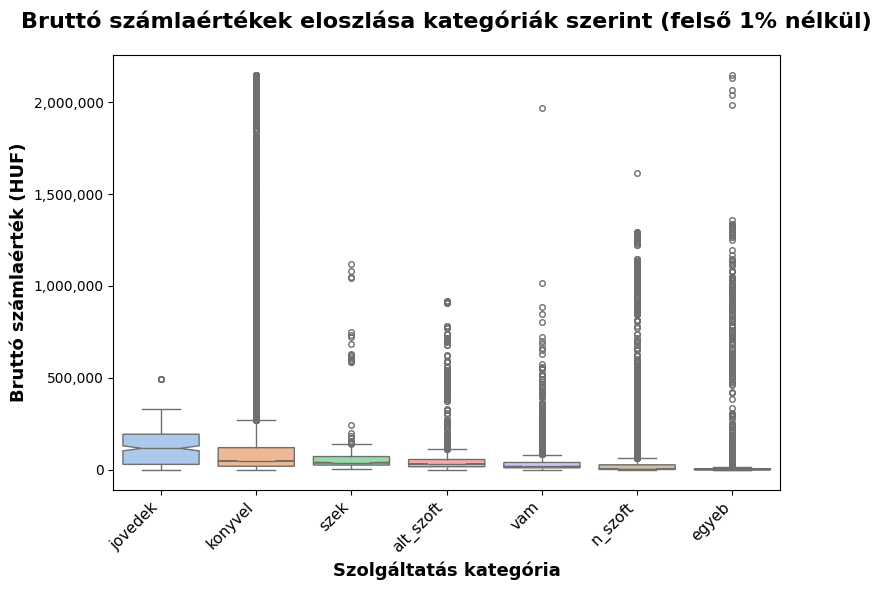

Az ábráról lehagytuk a 1369 db legmagasabb értékű számlát (a felső 1%-ot), hogy a dobozok olvashatóak maradjanak.


In [19]:
# 1. Adatok előkészítése
# A Boxplot-hoz a teljes 'df' adatbázist használjuk a kategóriák közötti összehasonlítás végett.
# A jobb olvashatóság érdekében szűrjük az extrém nagy értékeket (pl. felső 1%), de jelezzük a szövegben.
q99 = df['X_BRUTTO_HUF'].quantile(0.99)
df_filtered = df[df['X_BRUTTO_HUF'] < q99]

# Kategóriák sorrendjének meghatározása a medián alapján
order = df_filtered.groupby('KATEGORIA')['X_BRUTTO_HUF'].median().sort_values(ascending=False).index

# 2. A Boxplot elkészítése
plt.figure(figsize=(8, 6))
# sns.set_style("ticks")

boxplot = sns.boxplot(
    data=df_filtered, 
    x='KATEGORIA', 
    y='X_BRUTTO_HUF', 
    order=order, 
    palette='pastel',
    notch=True, # Mutatja a medián konfidencia intervallumát
    fliersize=4 # Kiugró értékek mérete
)

plt.title('Bruttó számlaértékek eloszlása kategóriák szerint (felső 1% nélkül)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Szolgáltatás kategória', fontsize=13, fontweight='bold')
plt.ylabel('Bruttó számlaérték (HUF)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)

# Értékek tengelyformázása (ezres elválasztó)
import matplotlib.ticker as ticker
boxplot.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

# Emlékeztető a szűrésről
print(f"Az ábráról lehagytuk a {len(df)-len(df_filtered)} db legmagasabb értékű számlát (a felső 1%-ot), hogy a dobozok olvashatóak maradjanak.")

## 5. Vizualizáció: Vállalati demográfia és költés kapcsolata (Hőtérkép)

Végül egy **Hőtérkép (Heatmap)** segítségével vizsgáljuk meg az összefüggést a **Vállalatméret**, a **TEAOR kategória** (főtevékenység) és az **összesített költés** között. Ez a vizualizáció segít azonosítani a legjelentősebb "piaci szeleteket".

**Módszertani megjegyzés:** Ebben a lépésben a `szamla_unique` objektumot használjuk a cégekhez rendelve, mivel a célunk a *vállalatok* teljes adminisztratív költésének vizsgálata demográfiai bontásban, nem pedig a szolgáltatási kategóriák összehasonlítása. Így elkerüljük az átfedő kategóriák miatti halmozódást.

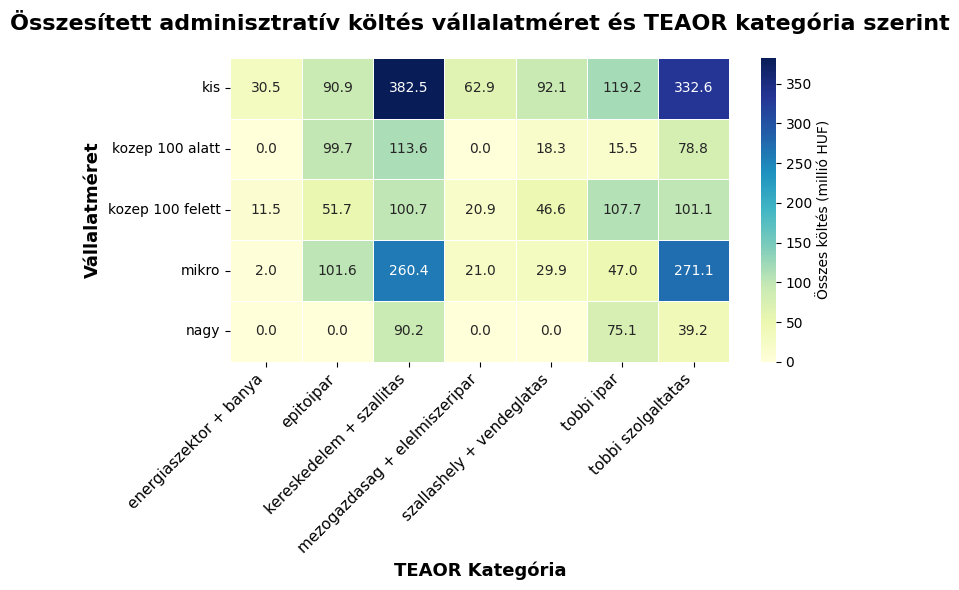

In [20]:
# 1. Adatok előkészítése
# Összekapcsoljuk az egyedi számlákat a vállalati adatokkal
df_unique_with_demog = pd.merge(szamla_unique, gazdmut, left_on='V_ADOSZAM_TORZSSZAM_DEP', right_on='AA_AZON', how='left')

# Pivot tábla létrehozása: Vállalatméret x TEAOR_KATEGORIA, érték: Összes költés
heatmap_data = df_unique_with_demog.pivot_table(
    values='X_BRUTTO_HUF', 
    index='VALLALATMERET', 
    columns='TEAOR_KATEGORIA', 
    aggfunc='sum', 
    fill_value=0 # Ha nincs adat, legyen 0
)

# 2. A Hőtérkép elkészítése
plt.figure(figsize=(8, 6))

sns.heatmap(
    heatmap_data / 1e6, # Milliárd HUF-ban jelenítjük meg az értékeket
    annot=True, # Értékek megjelenítése a cellákban
    fmt=".1f", # Tizedesjegy formátum
    cmap='YlGnBu', # Színpaletta
    linewidths=.5,
    cbar_kws={'label': 'Összes költés (millió HUF)'}
)

plt.title('Összesített adminisztratív költés vállalatméret és TEAOR kategória szerint', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('TEAOR Kategória', fontsize=13, fontweight='bold')
plt.ylabel('Vállalatméret', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)

plt.tight_layout()
plt.show()

## 6. Vizualizáció: Szolgáltatási mix vállalatméret szerint

Ez az ábra azt mutatja meg, hogy a különböző méretű vállalatoknál **milyen az adminisztratív költések belső aránya**. Ez választ ad arra, hogy például a mikrovállalkozásoknál is ugyanannyira fontos-e a szoftvervásárlás, mint a nagyvállalatoknál, vagy náluk a hagyományos könyvelés dominál.

**Módszertani megjegyzés:** 100%-ra normált (stacked) sávdiagramot használunk, hogy a volumenvédbeli különbségek ne nyomják el a strukturális különbségeket.

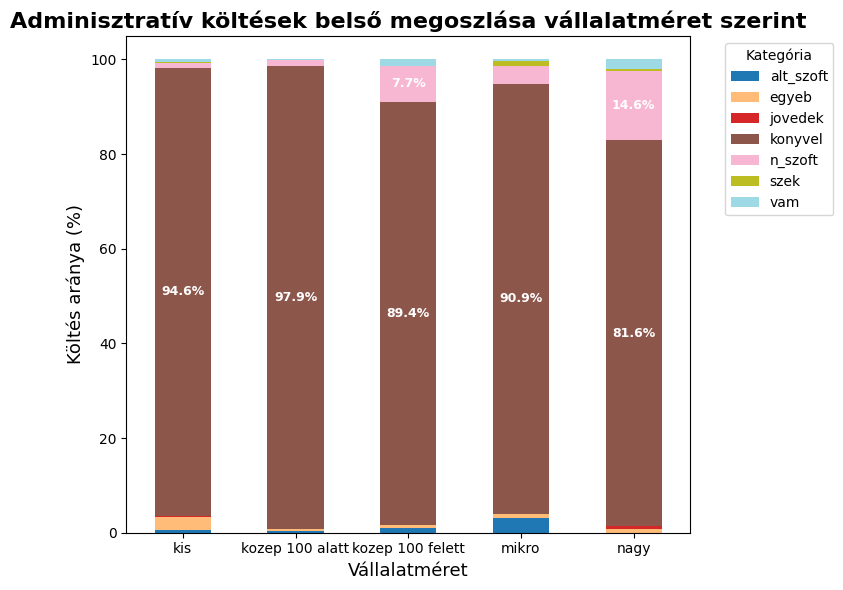

In [21]:
# 1. Adatok előkészítése
# Csoportosítás méret és kategória szerint
pivot_df = df.groupby(['VALLALATMERET', 'KATEGORIA'])['X_BRUTTO_HUF'].sum().unstack()

# Soronkénti normalizálás (hogy minden sáv 100%-ig érjen)
pivot_norm = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# 2. Vizualizáció
ax = pivot_norm.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='tab20')

plt.title('Adminisztratív költések belső megoszlása vállalatméret szerint', fontsize=16, fontweight='bold')
plt.ylabel('Költés aránya (%)', fontsize=13)
plt.xlabel('Vállalatméret', fontsize=13)
plt.legend(title='Kategória', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Százalékos értékek ráírása a sávokra (csak ha elég nagy a szelet)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # Csak 5% feletti szeleteknél írjuk ki
        x, y = p.get_xy() 
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Vizualizáció: Költési koncentráció (Pareto-elemzés)

Végül megvizsgáljuk a **számlák érték szerinti koncentrációját**. Egy tipikus adóhatósági kérdés, hogy a számlák mekkora része adja a teljes forgalom döntő többségét. Ezt egy kumulatív görbével szemléltetjük.

**Módszertani megjegyzés:** A számlákat érték szerint csökkenő sorrendbe állítjuk, majd kiszámítjuk a kumulatív összegüket és a darabszámuk kumulatív arányát.

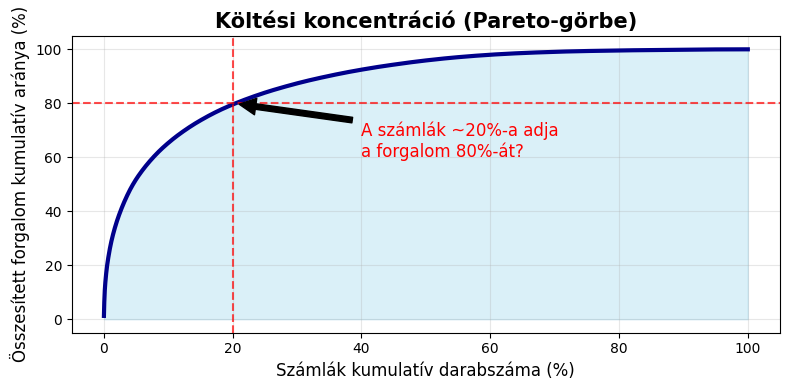

In [22]:
# 1. Adatok előkészítése
amounts = szamla_unique['X_BRUTTO_HUF'].sort_values(ascending=False).values
cum_amounts = np.cumsum(amounts)
cum_percentage_amounts = 100 * cum_amounts / cum_amounts[-1]
cum_percentage_counts = 100 * np.arange(1, len(amounts) + 1) / len(amounts)

# 2. Vizualizáció
plt.figure(figsize=(8, 4))
plt.plot(cum_percentage_counts, cum_percentage_amounts, color='darkblue', linewidth=3)
plt.fill_between(cum_percentage_counts, cum_percentage_amounts, color='skyblue', alpha=0.3)

# 80-20-as szabály jelölése
plt.axvline(x=20, color='red', linestyle='--', alpha=0.7)
plt.axhline(y=80, color='red', linestyle='--', alpha=0.7)

plt.title('Költési koncentráció (Pareto-görbe)', fontsize=15, fontweight='bold')
plt.xlabel('Számlák kumulatív darabszáma (%)', fontsize=12)
plt.ylabel('Összesített forgalom kumulatív aránya (%)', fontsize=12)
plt.grid(True, alpha=0.3)

# Jelölés értelmezése
plt.annotate('A számlák ~20%-a adja\na forgalom 80%-át?', xy=(20, 80), xytext=(40, 60),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12, color='red')

plt.tight_layout()
plt.show()

## 8. Vizualizáció: Tranzakciószám és átlagos számlaérték összefüggése

Ebben a vizualizációban kategóriánként vizsgáljuk meg a **szolgáltatás volumenét** (hány számla készült) és a **fajlagos költségét** (átlagos számlaérték). 

**Szakmai indoklás:** Ez a nézet segít a kategóriák "pozicionálásában". Azonosíthatjuk a:
* **High-volume, Low-cost:** Gyakori, rutinjellegű tételek (pl. havi könyvelési díj).
* **Low-volume, High-cost:** Ritka, de nagy értékű beruházások (pl. éves szoftverlicenc vagy audit).

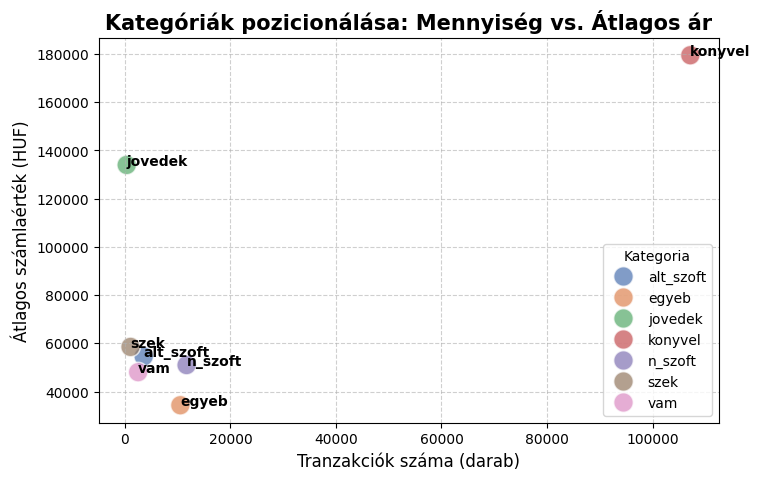

In [23]:
# 1. Adatok aggregálása kategóriák szerint
scatter_data = df.groupby('KATEGORIA').agg({
    'ESST_ID': 'count',
    'X_BRUTTO_HUF': 'mean'
}).reset_index()
scatter_data.columns = ['Kategoria', 'Szamlak_Szama', 'Atlagos_Ertek']

# 2. Vizualizáció
plt.figure(figsize=(8, 5))
sns.scatterplot(data=scatter_data, x='Szamlak_Szama', y='Atlagos_Ertek', s=200, hue='Kategoria', palette='deep', alpha=0.7)

# Feliratok hozzáadása a pontokhoz
for i in range(scatter_data.shape[0]):
    plt.text(scatter_data.Szamlak_Szama[i]+0.2, scatter_data.Atlagos_Ertek[i], 
             scatter_data.Kategoria[i], fontsize=10, weight='semibold')

plt.title('Kategóriák pozicionálása: Mennyiség vs. Átlagos ár', fontsize=15, fontweight='bold')
plt.xlabel('Tranzakciók száma (darab)', fontsize=12)
plt.ylabel('Átlagos számlaérték (HUF)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 9. Vizualizáció: Számlaértékek eloszlásának finomszerkezete (KDE)

A boxplot után egy **Kernel Density Estimate (KDE)** ábrával nézzük meg, hogy a számlaösszegek eloszlása milyen mintázatot követ. Itt nem az egyes értékek, hanem a költési "szintek" sűrűsége a lényeg.

**Szakmai indoklás:** Ha az ábrán több csúcsot (multimodális eloszlás) látunk, az azt jelenti, hogy egy kategórián belül jól elkülöníthető árazási szintek vannak (pl. van egy "alap" és egy "prémium" szolgáltatási kör), ami fontos információ a piaci szegmentációhoz.

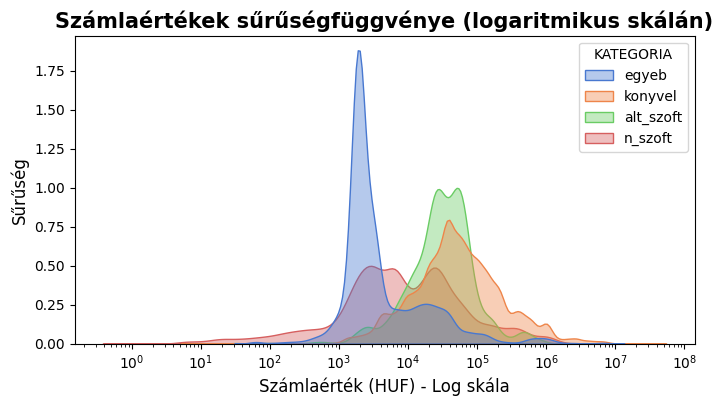

In [24]:
# 1. Vizualizáció
plt.figure(figsize=(8, 4))

# A top 4 legforgalmasabb kategória kiválasztása, hogy átlátható maradjon
top_categories = df['KATEGORIA'].value_counts().nlargest(4).index
df_top = df[df['KATEGORIA'].isin(top_categories)]

# Logaritmikus skálát használunk az X tengelyen, mert a számlaértékek több nagyságrendet fognak át
sns.kdeplot(data=df_top, x='X_BRUTTO_HUF', hue='KATEGORIA', fill=True, common_norm=False, palette='muted', alpha=.4, log_scale=True)

plt.title('Számlaértékek sűrűségfüggvénye (logaritmikus skálán)', fontsize=15, fontweight='bold')
plt.xlabel('Számlaérték (HUF) - Log skála', fontsize=12)
plt.ylabel('Sűrűség', fontsize=12)
plt.show()

## 11. Vizualizáció: Átlagos költések stabilitása (Point Plot)

Ez az ábra a kategóriák közötti **átlagos számlaértékeket** és azok **95%-os konfidencia-intervallumát** mutatja be.

**Szakmai indoklás:** Nem minden átlag egyenértékű. Ha a függőleges vonal (hibasáv) rövid, az azt jelenti, hogy az adott kategóriában a számlák összege nagyon hasonló (kiszámítható piac). Ha a vonal hosszú, a költések szóródása óriási, így az átlag kevésbé reprezentatív. Ez kritikus információ a költségtervezésnél.

C:\Users\USER\AppData\Local\Temp\ipykernel_7296\4024674914.py:4: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


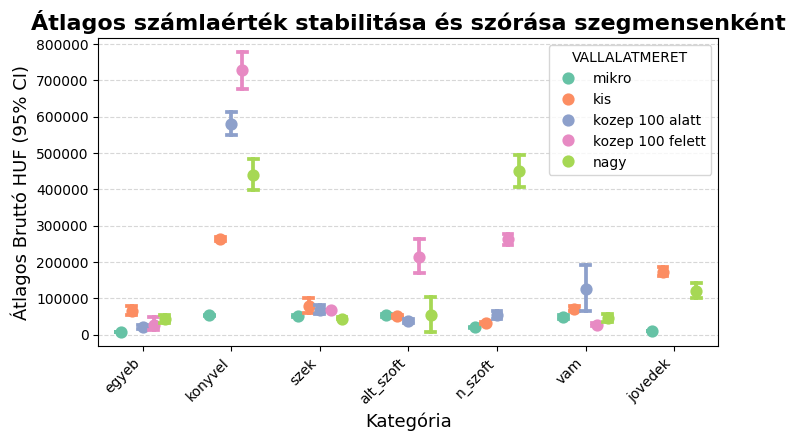

In [25]:
# 1. Vizualizáció
plt.figure(figsize=(8, 4))

sns.pointplot(
    data=df, 
    x='KATEGORIA', 
    y='X_BRUTTO_HUF', 
    hue='VALLALATMERET',
    join=False,      # Ne kösse össze a pontokat
    dodge=0.5,       # Tolja el egymástól a vállalatméreteket az olvashatóságért
    capsize=.1,      # Kis talpak a hibasávok végére
    palette='Set2'
)

plt.title('Átlagos számlaérték stabilitása és szórása szegmensenként', fontsize=16, fontweight='bold')
plt.xlabel('Kategória', fontsize=13)
plt.ylabel('Átlagos Bruttó HUF (95% CI)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 5. Adatvezérelt szegmentáció: K-means klaszterezés
Ebben az utolsó technikai szakaszban túllépünk a rögzített kategóriákon (vállalatméret), és megvizsgáljuk, hogy maguk az adatok milyen csoportokba rendeződnek. A célunk az ügyfelek **költési profil szerinti szegmentálása**.

**Módszer:** K-means algoritmust használunk a vállalatok éves összköltése és tranzakciószáma alapján. Ez segít azonosítani a "stratégiai partnereket", a "rutinvásárlókat" és az "eseti ügyfeleket".

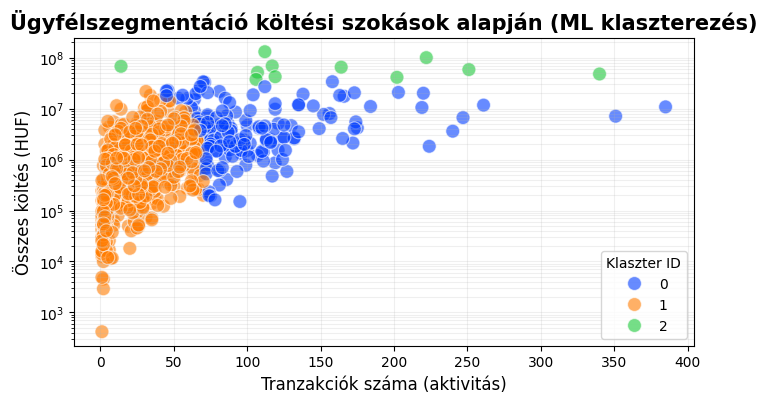

Klaszterek jellemzői (átlagértékek):


,Total_Spend,Transaction_Count
Cluster,,
0,6.571825e+06,106.512658
1,1.394662e+06,25.210250
2,6.498200e+07,159.454545


In [26]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Adatok előkészítése (Cégenkénti összesítő)
customer_data = df_unique_with_demog.groupby('AA_AZON').agg({
    'X_BRUTTO_HUF': 'sum',
    'ESST_ID': 'count'
}).reset_index()
customer_data.columns = ['AA_AZON', 'Total_Spend', 'Transaction_Count']

# 2. Skálázás (Fontos a távolság alapú algoritmusoknál!)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_data[['Total_Spend', 'Transaction_Count']])

# 3. Klaszterezés (legyen 3 csoport: Alacsony, Közepes, Magas értékű ügyfelek)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_data['Cluster'] = kmeans.fit_predict(scaled_features)

# 4. Vizualizáció
plt.figure(figsize=(8, 4))
sns.scatterplot(
    data=customer_data, 
    x='Transaction_Count', 
    y='Total_Spend', 
    hue='Cluster', 
    palette='bright',
    s=100, alpha=0.6
)

plt.title('Ügyfélszegmentáció költési szokások alapján (ML klaszterezés)', fontsize=15, fontweight='bold')
plt.xlabel('Tranzakciók száma (aktivitás)', fontsize=12)
plt.ylabel('Összes költés (HUF)', fontsize=12)
plt.yscale('log') # Log skála a jobb láthatóságért, ha nagy a szórás
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(title='Klaszter ID')
plt.show()

print("Klaszterek jellemzői (átlagértékek):")
display(customer_data.groupby('Cluster')[['Total_Spend', 'Transaction_Count']].mean())